<a href="https://colab.research.google.com/github/vishnu17306/maize-leaf-disease-cnn/blob/main/DL_CIE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
!pip install idx2numpy -q
import idx2numpy
import numpy as np

path = "/content/drive/MyDrive/mnist-dataset"

x_train_full = idx2numpy.convert_from_file(f"{path}/train-images.idx3-ubyte")
y_train_full = idx2numpy.convert_from_file(f"{path}/train-labels.idx1-ubyte")
x_test = idx2numpy.convert_from_file(f"{path}/t10k-images.idx3-ubyte")
y_test = idx2numpy.convert_from_file(f"{path}/t10k-labels.idx1-ubyte")

print(x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [18]:
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

from tensorflow.keras.utils import to_categorical
num_classes = 10
y_train_full_cat = to_categorical(y_train_full, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full_cat, test_size=0.1, random_state=42, stratify=y_train_full
)

print("Train shape:", x_train.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)

Train shape: (54000, 28, 28, 1)
Validation shape: (6000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_cnn(kernel_size=(3, 3), filters=(32, 64)):
    model = Sequential([
        Conv2D(filters[0], kernel_size, activation='relu', input_shape=(28, 28, 1), padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(filters[1], kernel_size, activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn(kernel_size=(3, 3))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_cnn(kernel_size=(3, 3), filters=(32, 64)):
    model = Sequential([
        Conv2D(filters[0], kernel_size, activation='relu', input_shape=(28, 28, 1), padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(filters[1], kernel_size, activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn(kernel_size=(3, 3))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 158ms/step - accuracy: 0.9033 - loss: 0.3135 - val_accuracy: 0.9755 - val_loss: 0.0807
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 164ms/step - accuracy: 0.9699 - loss: 0.1004 - val_accuracy: 0.9838 - val_loss: 0.0580
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 67s 160ms/step - accuracy: 0.9780 - loss: 0.0742 - val_accuracy: 0.9847 - val_loss: 0.0539
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 163ms/step - accuracy: 0.9819 - loss: 0.0588 - val_accuracy: 0.9882 - val_loss: 0.0427
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 159ms/step - accuracy: 0.9839 - loss: 0.0513 - val_accuracy: 0.9888 - val_loss: 0.0423
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 157ms/step - accuracy: 0.9866 - loss: 0.0446 - val_accuracy: 0.9897 - val_loss: 0.0425
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 161ms/step - accuracy: 0.9882 - loss: 0.0387 - val_accuracy: 0.9893 - val_loss: 0.0378
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 67s 158ms/step - accuracy: 0.9897 - loss: 0

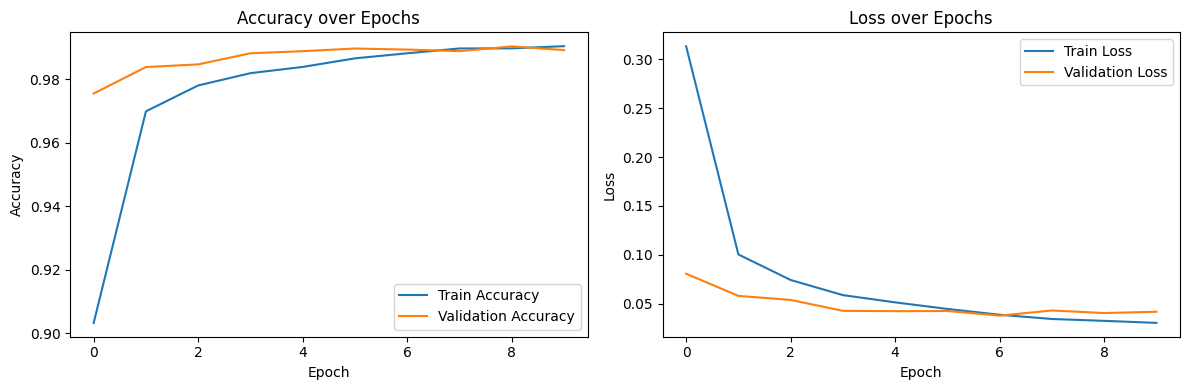

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9916
Test Loss: 0.0259


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


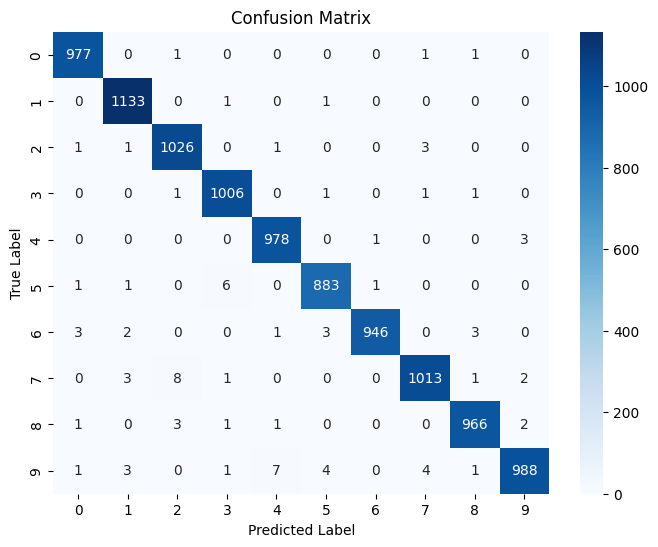

              precision    recall  f1-score   support

           0     0.9929    0.9969    0.9949       980
           1     0.9913    0.9982    0.9947      1135
           2     0.9875    0.9942    0.9908      1032
           3     0.9902    0.9960    0.9931      1010
           4     0.9899    0.9959    0.9929       982
           5     0.9899    0.9899    0.9899       892
           6     0.9979    0.9875    0.9927       958
           7     0.9912    0.9854    0.9883      1028
           8     0.9928    0.9918    0.9923       974
           9     0.9930    0.9792    0.9860      1009

    accuracy                         0.9916     10000
   macro avg     0.9916    0.9915    0.9916     10000
weighted avg     0.9916    0.9916    0.9916     10000



In [24]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, digits=4))

In [15]:
kernel_sizes = [(3, 3), (5, 5), (7, 7)]
results = {}

for k in kernel_sizes:
    print("--- Training with kernel size", k, "---")
    m = build_cnn(kernel_size=k)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=5, batch_size=128, verbose=0)
    loss, acc = m.evaluate(x_test, y_test_cat, verbose=0)
    results[k] = {'test_acc': acc, 'test_loss': loss}
    print("Kernel", k, "-> Test Accuracy:", round(acc, 4), "Test Loss:", round(loss, 4))

labels = [str(k) for k in results.keys()]
accs = [results[k]['test_acc'] for k in results.keys()]
losses = [results[k]['test_loss'] for k in results.keys()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, accs, color='seagreen')
axes[0].set_title('Test Accuracy vs Kernel Size')
axes[1].bar(labels, losses, color='indianred')
axes[1].set_title('Test Loss vs Kernel Size')
plt.tight_layout()
plt.show()

--- Training with kernel size (3, 3) ---
Kernel (3, 3) -> Test Accuracy: 0.9896 Test Loss: 0.0299
--- Training with kernel size (5, 5) ---
Kernel (5, 5) -> Test Accuracy: 0.9911 Test Loss: 0.0245
--- Training with kernel size (7, 7) ---


KeyboardInterrupt: 

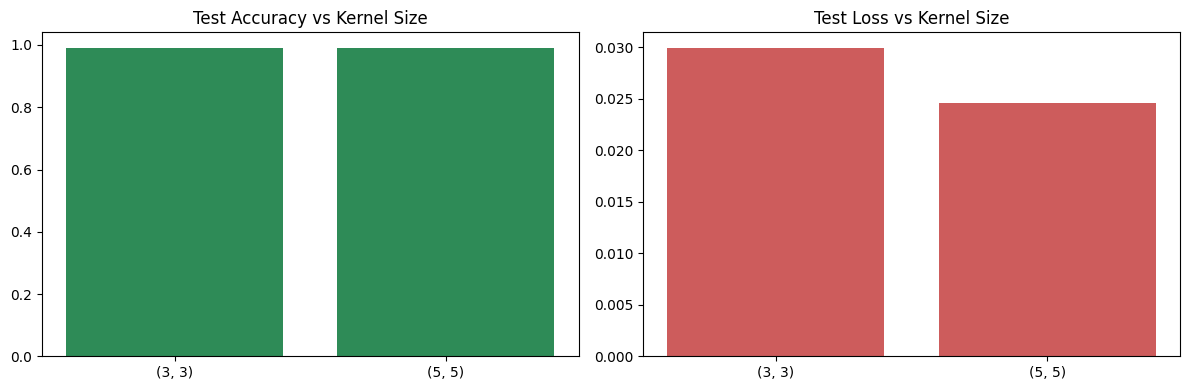

In [27]:
labels = [str(k) for k in results.keys()]
accs = [results[k]['test_acc'] for k in results.keys()]
losses = [results[k]['test_loss'] for k in results.keys()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, accs, color='seagreen')
axes[0].set_title('Test Accuracy vs Kernel Size')
axes[1].bar(labels, losses, color='indianred')
axes[1].set_title('Test Loss vs Kernel Size')
plt.tight_layout()
plt.show()

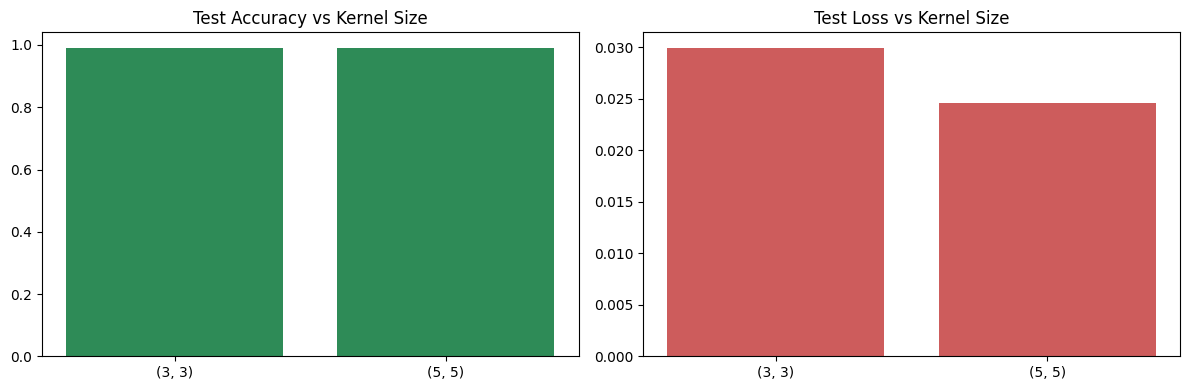

In [28]:
labels = [str(k) for k in results.keys()]
accs = [results[k]['test_acc'] for k in results.keys()]
losses = [results[k]['test_loss'] for k in results.keys()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, accs, color='seagreen')
axes[0].set_title('Test Accuracy vs Kernel Size')
axes[1].bar(labels, losses, color='indianred')
axes[1].set_title('Test Loss vs Kernel Size')
plt.tight_layout()
plt.show()